**Dry Bean Variety Classification Using Machine Learning**

**Data Collection:**

In [ ]:
import pandas as pd
df=pd.read_excel("/content/Dry_Bean_Dataset.xlsx")


***Data Preprocessing - Data Cleaning:***



In [ ]:
print(df.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
print(df.isnull().sum())

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [ ]:
#Descriptive statistics

In [ ]:
import numpy as np
numeric_df = df.select_dtypes(include=np.number)
numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


In [ ]:
df["Class"].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [ ]:
df.dtypes

,0
Area,int64
Perimeter,float64
MajorAxisLength,float64
MinorAxisLength,float64
AspectRation,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Solidity,float64


In [ ]:
X=df.drop("Class",axis=1)
y=df["Class"]
X = X.astype(float)
correlation = X.corr()

# Display correlation matrix
print(correlation)

                     Area  Perimeter  MajorAxisLength  MinorAxisLength  \
Area             1.000000   0.966722         0.931834         0.951602   
Perimeter        0.966722   1.000000         0.977338         0.913179   
MajorAxisLength  0.931834   0.977338         1.000000         0.826052   
MinorAxisLength  0.951602   0.913179         0.826052         1.000000   
AspectRation     0.241735   0.385276         0.550335        -0.009161   
Eccentricity     0.267481   0.391066         0.541972         0.019574   
ConvexArea       0.999939   0.967689         0.932607         0.951339   
EquivDiameter    0.984968   0.991380         0.961733         0.948539   
Extent           0.054345  -0.021160        -0.078062         0.145957   
Solidity        -0.196585  -0.303970        -0.284302        -0.155831   
roundness       -0.357530  -0.547647        -0.596358        -0.210344   
Compactness     -0.268067  -0.406857        -0.568377        -0.015066   
ShapeFactor1    -0.847958  -0.864623  

In [ ]:
print(correlation.isnull().sum().sum())

0


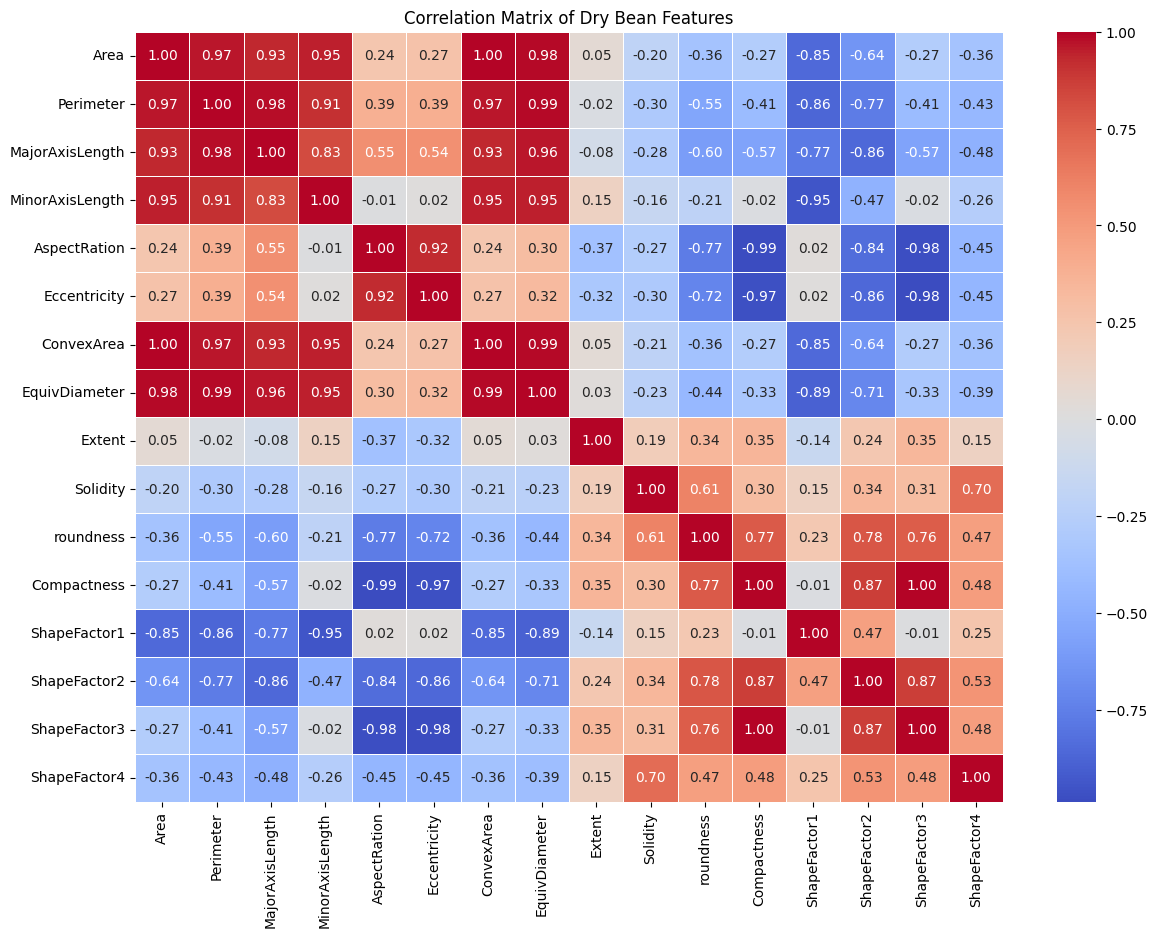

In [ ]:
 #5. Correlation Matrix
# --------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Dry Bean Features")
plt.show()

In [ ]:

import numpy as np
corr = X.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = upper.stack().sort_values(ascending=False)

print(high_corr[high_corr > 0.80])

Area             ConvexArea         0.999939
Compactness      ShapeFactor3       0.998686
Perimeter        EquivDiameter      0.991380
AspectRation     Compactness        0.987687
ConvexArea       EquivDiameter      0.985226
Area             EquivDiameter      0.984968
Eccentricity     ShapeFactor3       0.981058
AspectRation     ShapeFactor3       0.978592
Perimeter        MajorAxisLength    0.977338
Eccentricity     Compactness        0.970313
Perimeter        ConvexArea         0.967689
Area             Perimeter          0.966722
MajorAxisLength  EquivDiameter      0.961733
Area             MinorAxisLength    0.951602
MinorAxisLength  ConvexArea         0.951339
                 EquivDiameter      0.948539
                 ShapeFactor1       0.947204
MajorAxisLength  ConvexArea         0.932607
Area             MajorAxisLength    0.931834
AspectRation     Eccentricity       0.924293
Perimeter        MinorAxisLength    0.913179
EquivDiameter    ShapeFactor1       0.892741
ShapeFacto

**Exploratory Data Analysis (EDA):**

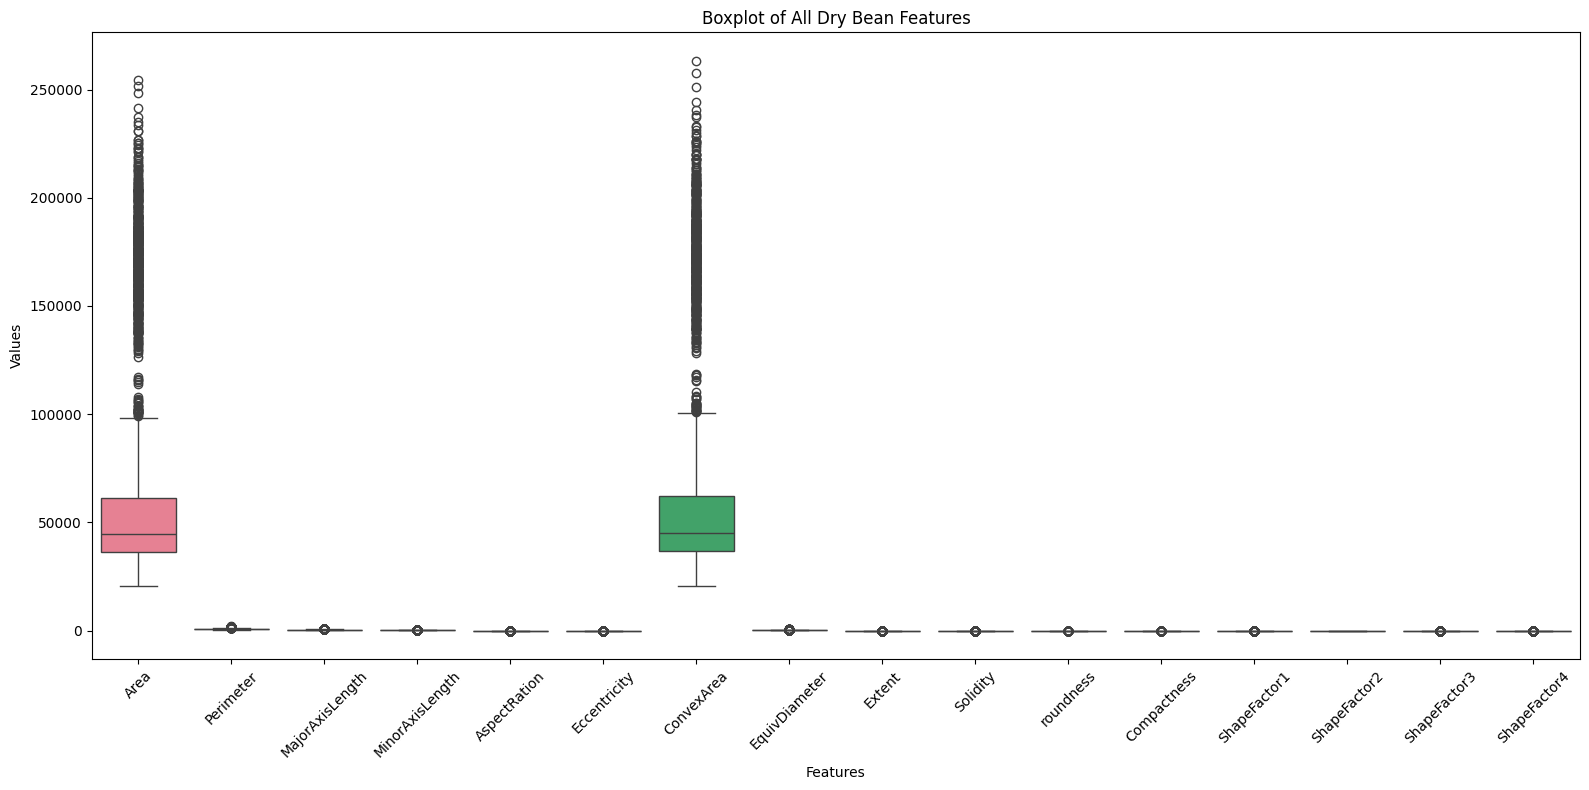

In [ ]:
#Outlier Detection
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))

sns.boxplot(data=X)

plt.title("Boxplot of All Dry Bean Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
# Several features contain potential outliers.
# These observations are retained because they may represent genuine bean measurements.

In [ ]:
#2. Detect outliers using IQR(Interquartile Range)

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((X < lower) | (X > upper))

print(outliers.sum())

Area               551
Perimeter          500
MajorAxisLength    379
MinorAxisLength    569
AspectRation       473
Eccentricity       843
ConvexArea         550
EquivDiameter      526
Extent             275
Solidity           778
roundness           91
Compactness        109
ShapeFactor1       533
ShapeFactor2         0
ShapeFactor3       195
ShapeFactor4       767
dtype: int64


 **Target Encoding:**

In [ ]:
#Encode target

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
# Encode target
y_encoded = le.fit_transform(y)


 **Split Data into Training and Testing Sets:**

In [ ]:
#Split the dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split( X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded)

Dry Bean classes are imbalanced. stratify=y_encoded makes sure the training and testing sets maintain approximately the same class proportions.

**Feature Selection:**


In [ ]:
# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]

print("Selected features:")
print(selected_features)

Selected features:
Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'ConvexArea', 'EquivDiameter', 'Compactness',
       'ShapeFactor1', 'ShapeFactor2'],
      dtype='object')


Select KBest, which selected the top 10 features based on ANOVA F-score.

**Feature Scaling:**

In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)



"The boxplot analysis indicates the presence of several potential outliers across multiple numerical features. Since these observations represent actual physical measurements of dry beans, the detected outliers may be genuine observations rather than errors. Therefore, they were not removed solely based on the IQR rule."

In [ ]:
#Verify the scaled data

In [ ]:
print("Mean of first feature:", X_train_scaled[:, 0].mean())
print("Standard deviation of first feature:", X_train_scaled[:, 0].std())

Mean of first feature: 1.1877183863734225e-16
Standard deviation of first feature: 0.9999999999999999


 **Build the ML Model:**

In [ ]:
#Classification – 5 Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

# Define models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}



**Model Evaluation:**

In [ ]:
# Train and evaluate models
results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train_scaled, y_train)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print("\n", "="*50)
    print(name)
    print("="*50)

    print("Accuracy:", accuracy)

    print("\nClassification Report:")

    print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))


Logistic Regression
Accuracy: 0.9089239809034153

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.97      0.85      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.95      0.93       326
    DERMASON       0.91      0.89      0.90       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.93      0.94      0.94       406
        SIRA       0.82      0.87      0.84       527

    accuracy                           0.91      2723
   macro avg       0.93      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723


Decision Tree
Accuracy: 0.8740359897172236

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.84      0.83      0.83       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.87      0.89      0.88       326
    DERMASON       0.87      0.88      0.87 

In [ ]:
print("\nModel Comparison")

for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")


Model Comparison
Logistic Regression: 0.9089
Decision Tree: 0.8740
Random Forest: 0.9041
SVM: 0.9041
KNN: 0.9038


Logistic Regression performed the best with 90.89% accuracy.
Random Forest and SVM both achieved 90.41%, very close to Logistic Regression.
KNN achieved 90.38%, also very competitive.
Decision Tree performed the lowest at 87.40%.


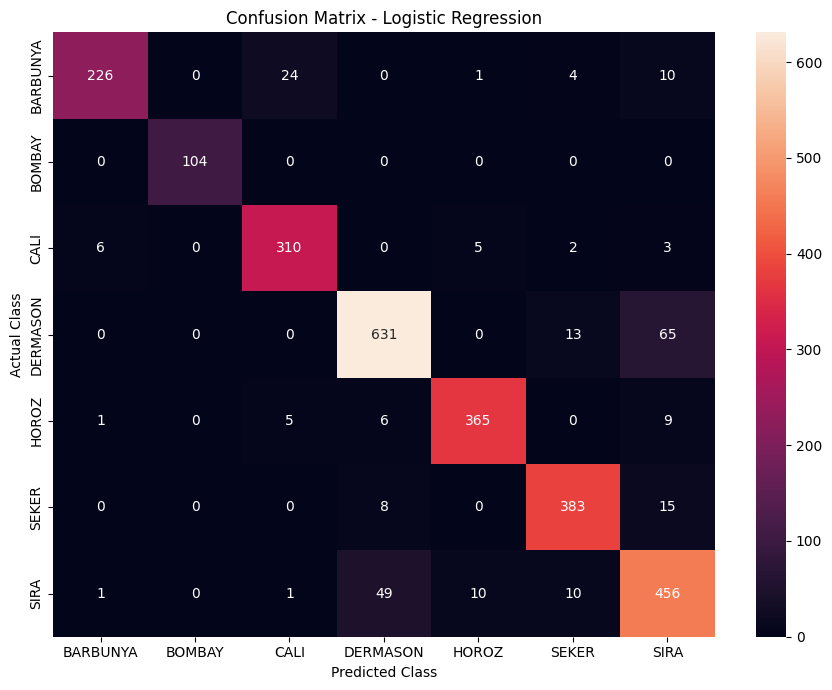

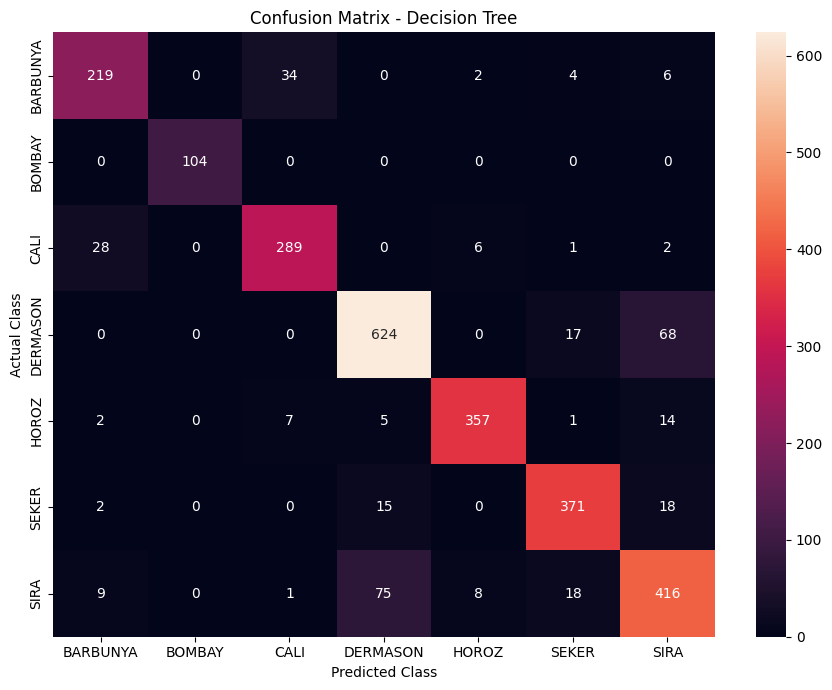

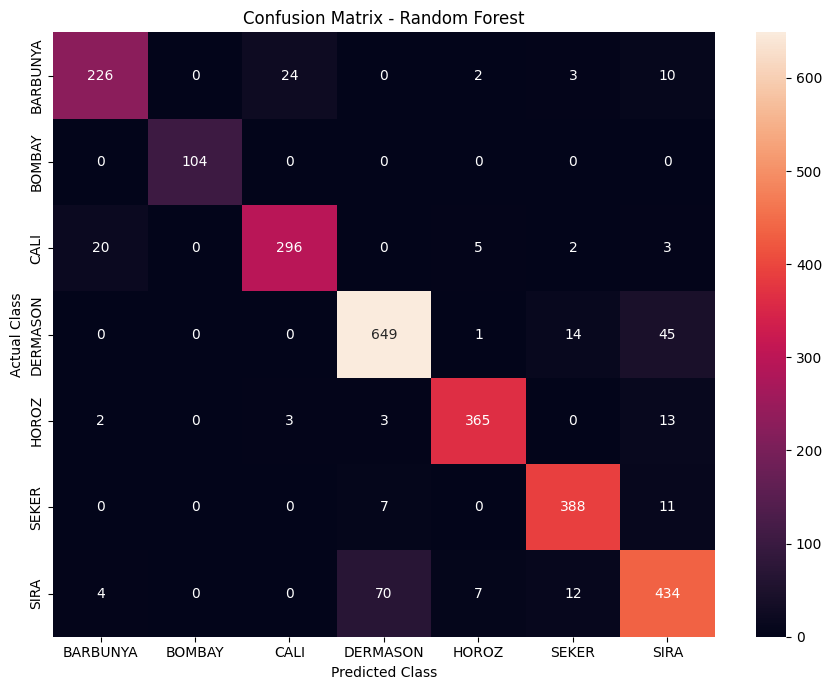

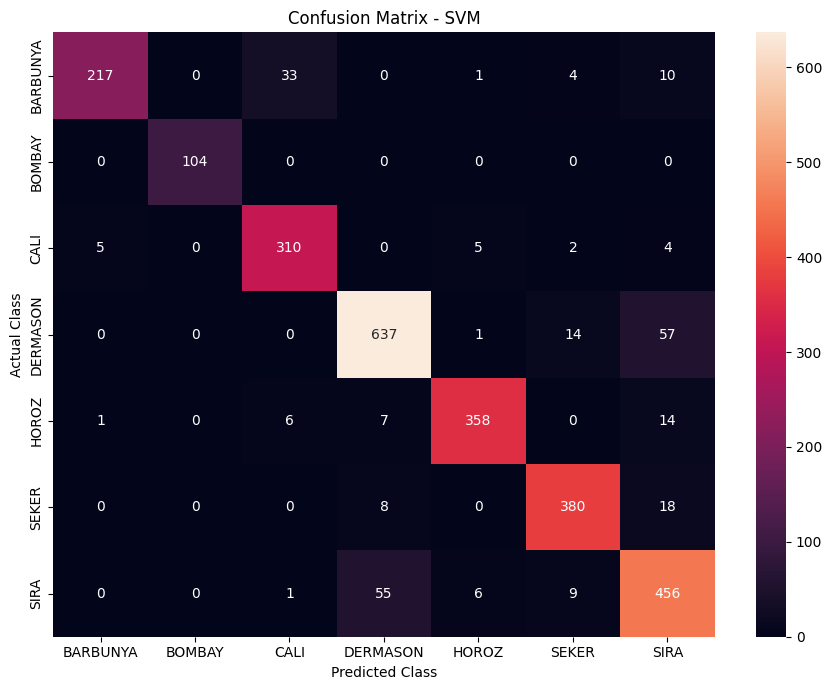

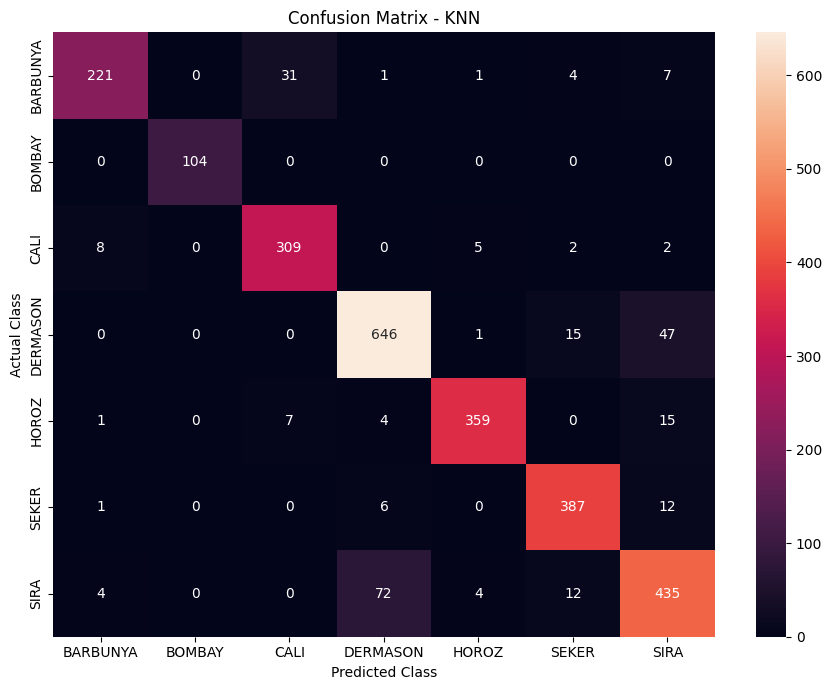

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
for name, model in models.items():

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(9, 7))


    class_labels = le.classes_

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

 **Hyperparameter Tuning:**

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10888, 16)
(2723, 16)
(10888,)
(2723,)


In [ ]:
#Evaluate on test data

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_lr.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Macro F1:", grid_lr.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'C': 100, 'solver': 'lbfgs'}
Best CV Macro F1: 0.9306875917116156


In [ ]:
best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Tuned Logistic Regression")
print("-------------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr_tuned))

print("Macro Precision:",
      precision_score(
          y_test,
          y_pred_lr_tuned,
          average='macro'
      ))

print("Macro Recall:",
      recall_score(
          y_test,
          y_pred_lr_tuned,
          average='macro'
      ))

print("Macro F1:",
      f1_score(
          y_test,
          y_pred_lr_tuned,
          average='macro'
      ))

print("Weighted F1:",
      f1_score(
          y_test,
          y_pred_lr_tuned,
          average='weighted'
      ))

Tuned Logistic Regression
-------------------------
Accuracy: 0.9162688211531399
Macro Precision: 0.9333289087916109
Macro Recall: 0.927682518275246
Macro F1: 0.9301242655177615
Weighted F1: 0.9166195588438164


The tuned Logistic Regression achieved:

Accuracy: 91.63%
Macro Precision: 93.33%
Macro Recall: 92.77%
Macro F1: 93.01%
Weighted F1: 91.66%

This is better than your tuned Random Forest:

Accuracy: 90.60%
Macro F1: 91.96%

In [ ]:
from sklearn.metrics import classification_report

print("Final Tuned Logistic Regression Classification Report")
print("------------------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_lr_tuned,
        target_names=class_labels
    )
)

Final Tuned Logistic Regression Classification Report
------------------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.91      0.90      0.91       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.94      0.94      0.94       406
        SIRA       0.83      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



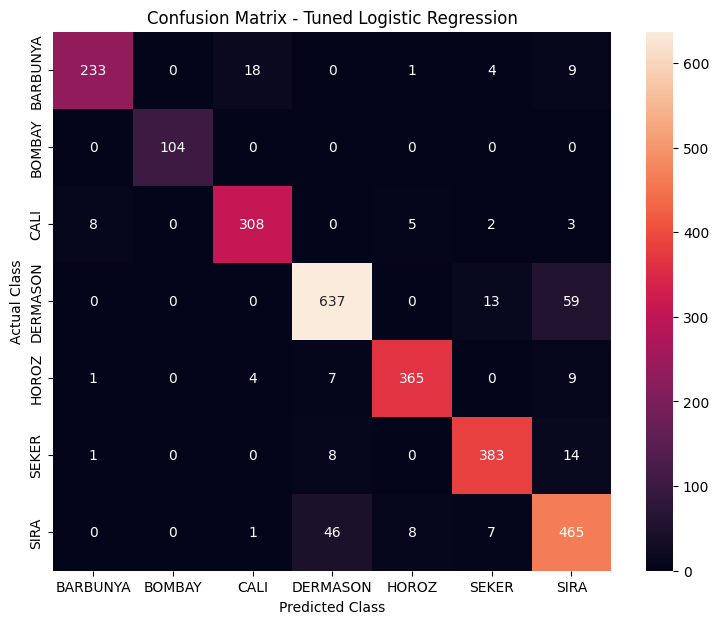

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr_tuned)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Tuned Logistic Regression")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

class_labels = le.classes_

print("Final Tuned Logistic Regression Classification Report")
print("------------------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_lr_tuned,
        target_names=class_labels
    )
)

Final Tuned Logistic Regression Classification Report
------------------------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.91      0.90      0.91       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.94      0.94      0.94       406
        SIRA       0.83      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



Conclusion:

The tuned Logistic Regression model achieved 91.63% accuracy and a macro F1-score of 93.01%, indicating strong classification performance across the seven Dry Bean varieties.

**Interpretation of Results (Conclusion):**

The Dry Bean Variety Classification Using Machine Learning project successfully developed and evaluated machine learning models for classifying seven different varieties of dry beans based on their physical characteristics.

Overall, the tuned Logistic Regression model was selected as the final model because it provided the best overall performance among the evaluated models. The results demonstrate that machine learning can effectively classify dry bean varieties using their measured physical characteristics, achieving more than 91% test accuracy.

**Future Work:**

The present study achieved promising results in classifying dry bean varieties using machine learning. However, several improvements can be explored in future work:
Advanced Feature Selection,Hyperparameter Optimization,Real-World Image-Based Classification.

In [ ]:
import joblib

# Save final tuned Logistic Regression model
joblib.dump(best_lr, "logistic_model.pkl")

# Save feature selection object
joblib.dump(selector, "feature_selector.pkl")

# Save StandardScaler
joblib.dump(scaler, "scaler.pkl")

# Save LabelEncoder
joblib.dump(le, "label_encoder.pkl")

print("All model files saved successfully!")

All model files saved successfully!
